# NYC Yellow Taxi 2026-05 — 데이터 로딩 비교 & EDA

1. Pandas vs Polars 로딩 비교
2. 결측치 처리
3. 중복 처리
4. 기본 EDA

In [1]:
import logging
import timeit

import pandas as pd
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s [%(levelname)s] %(message)s",
    datefmt="%H:%M:%S",
)
logger = logging.getLogger("taxi_eda")

PARQUET_PATH = "../data/raw/yellow_tripdata_2026-05.parquet"

## 1. Pandas vs Polars 로딩 비교

동일한 parquet 파일을 Pandas와 Polars 양쪽으로 로딩하여 로딩 시간, shape, dtype을 비교합니다.

In [2]:
# --- Pandas 로딩 ---
_loaded = {}
pandas_load_times = timeit.repeat(
    lambda: _loaded.__setitem__("df", pd.read_parquet(PARQUET_PATH)),
    number=1, repeat=3,
)
df_pd = _loaded["df"]
pandas_load_sec = min(pandas_load_times)

logger.info(f"[Pandas] 로딩 시간(3회 측정, timeit): {[f'{t:.3f}' for t in pandas_load_times]}초")
logger.info(f"[Pandas] 최소 로딩 시간: {pandas_load_sec:.3f}초")
logger.info(f"[Pandas] shape: {df_pd.shape}")
logger.info(f"[Pandas] 메모리 사용량: {df_pd.memory_usage(deep=True).sum() / 1024**2:.1f} MB")

17:02:38 [INFO] [Pandas] 로딩 시간(3회 측정, timeit): ['0.512', '0.147', '0.179']초


17:02:38 [INFO] [Pandas] 최소 로딩 시간: 0.147초


17:02:38 [INFO] [Pandas] shape: (4090836, 20)


17:02:38 [INFO] [Pandas] 메모리 사용량: 580.6 MB


In [3]:
# --- Polars 로딩 ---
_loaded = {}
polars_load_times = timeit.repeat(
    lambda: _loaded.__setitem__("df", pl.read_parquet(PARQUET_PATH)),
    number=1, repeat=3,
)
df_pl = _loaded["df"]
polars_load_sec = min(polars_load_times)

logger.info(f"[Polars] 로딩 시간(3회 측정, timeit): {[f'{t:.3f}' for t in polars_load_times]}초")
logger.info(f"[Polars] 최소 로딩 시간: {polars_load_sec:.3f}초")
logger.info(f"[Polars] shape: {df_pl.shape}")
logger.info(f"[Polars] 메모리 사용량: {df_pl.estimated_size('mb'):.1f} MB")

17:02:38 [INFO] [Polars] 로딩 시간(3회 측정, timeit): ['0.300', '0.174', '0.241']초


17:02:38 [INFO] [Polars] 최소 로딩 시간: 0.174초


17:02:38 [INFO] [Polars] shape: (4090836, 20)


17:02:38 [INFO] [Polars] 메모리 사용량: 550.1 MB


In [4]:
# --- 결과 비교 ---
comparison = pd.DataFrame({
    "항목": ["최소 로딩 시간(초, timeit x3)", "행 수", "열 수"],
    "Pandas": [round(pandas_load_sec, 3), df_pd.shape[0], df_pd.shape[1]],
    "Polars": [round(polars_load_sec, 3), df_pl.shape[0], df_pl.shape[1]],
})
logger.info(f"Polars가 Pandas보다 {pandas_load_sec / polars_load_sec:.2f}배 빠름")
logger.info(f"로딩 비교\n{comparison.to_string(index=False)}")
comparison

17:02:38 [INFO] Polars가 Pandas보다 0.84배 빠름


17:02:38 [INFO] 로딩 비교
                    항목      Pandas      Polars
최소 로딩 시간(초, timeit x3)       0.147       0.174
                   행 수 4090836.000 4090836.000
                   열 수      20.000      20.000


,항목,Pandas,Polars
0,"최소 로딩 시간(초, timeit x3)",0.147,0.174
1,행 수,4090836.000,4090836.000
2,열 수,20.000,20.000


In [5]:
# --- dtype 비교 ---
dtype_comparison = pd.DataFrame({
    "column": df_pd.columns,
    "pandas_dtype": df_pd.dtypes.astype(str).values,
    "polars_dtype": [str(dt) for dt in df_pl.dtypes],
})
logger.info(f"dtype 비교\n{dtype_comparison.to_string(index=False)}")
dtype_comparison

17:02:38 [INFO] dtype 비교
               column   pandas_dtype                             polars_dtype
             VendorID          int32                                    Int32
 tpep_pickup_datetime datetime64[us] Datetime(time_unit='us', time_zone=None)
tpep_dropoff_datetime datetime64[us] Datetime(time_unit='us', time_zone=None)
      passenger_count        float64                                    Int64
        trip_distance        float64                                  Float64
           RatecodeID        float64                                    Int64
   store_and_fwd_flag            str                                   String
         PULocationID          int32                                    Int32
         DOLocationID          int32                                    Int32
         payment_type          int64                                    Int64
          fare_amount        float64                                  Float64
                extra        float64   

,column,pandas_dtype,polars_dtype
0,VendorID,int32,Int32
1,tpep_pickup_datetime,datetime64[us],"Datetime(time_unit='us', time_zone=None)"
2,tpep_dropoff_datetime,datetime64[us],"Datetime(time_unit='us', time_zone=None)"
3,passenger_count,float64,Int64
4,trip_distance,float64,Float64
5,RatecodeID,float64,Int64
6,store_and_fwd_flag,str,String
7,PULocationID,int32,Int32
8,DOLocationID,int32,Int32
9,payment_type,int64,Int64


## 2. 결측치 처리

Pandas와 Polars 양쪽에서 컬럼별 결측치 현황을 확인하고 동일한 기준으로 처리합니다.

In [6]:
# --- Pandas 결측치 현황 ---
missing_pd = df_pd.isna().sum()
missing_pd = missing_pd[missing_pd > 0].sort_values(ascending=False)
missing_pd_pct = (missing_pd / len(df_pd) * 100).round(2)
missing_summary_pd = pd.DataFrame({"missing_count": missing_pd, "missing_pct": missing_pd_pct})
logger.info(f"[Pandas] 결측치 현황\n{missing_summary_pd.to_string()}")
missing_summary_pd

17:02:39 [INFO] [Pandas] 결측치 현황
                      missing_count  missing_pct
passenger_count              955371        23.35
RatecodeID                   955371        23.35
store_and_fwd_flag           955371        23.35
congestion_surcharge         955371        23.35
Airport_fee                  955371        23.35


,missing_count,missing_pct
passenger_count,955371,23.35
RatecodeID,955371,23.35
store_and_fwd_flag,955371,23.35
congestion_surcharge,955371,23.35
Airport_fee,955371,23.35


In [7]:
# --- Polars 결측치 현황 ---
null_counts = df_pl.null_count().row(0, named=True)
missing_summary_pl = (
    pd.Series(null_counts)
    .loc[lambda s: s > 0]
    .sort_values(ascending=False)
    .to_frame("missing_count")
)
missing_summary_pl["missing_pct"] = (missing_summary_pl["missing_count"] / df_pl.height * 100).round(2)
logger.info(f"[Polars] 결측치 현황\n{missing_summary_pl.to_string()}")
missing_summary_pl

17:02:39 [INFO] [Polars] 결측치 현황
                      missing_count  missing_pct
passenger_count              955371        23.35
RatecodeID                   955371        23.35
store_and_fwd_flag           955371        23.35
congestion_surcharge         955371        23.35
Airport_fee                  955371        23.35


,missing_count,missing_pct
passenger_count,955371,23.35
RatecodeID,955371,23.35
store_and_fwd_flag,955371,23.35
congestion_surcharge,955371,23.35
Airport_fee,955371,23.35


In [8]:
# --- 두 라이브러리 결측치 집계 일치 여부 확인 ---
assert missing_summary_pd["missing_count"].sort_index().equals(
    missing_summary_pl["missing_count"].sort_index()
), "Pandas와 Polars의 결측치 집계가 일치하지 않습니다."
logger.info("Pandas / Polars 결측치 집계 일치 확인 완료")

# 5개 컬럼(passenger_count, RatecodeID, store_and_fwd_flag,
# congestion_surcharge, Airport_fee)이 정확히 동일한 건수로 결측 -> 구조적 결측 의심
structural_missing_cols = [
    "passenger_count", "RatecodeID", "store_and_fwd_flag",
    "congestion_surcharge", "Airport_fee",
]
missing_mask = df_pd[structural_missing_cols[0]].isna()
payment0_mask = df_pd["payment_type"] == 0
overlap = (missing_mask & payment0_mask).sum()
logger.info(f"결측 행 수: {missing_mask.sum():,}")
logger.info(f"payment_type=0 행 수: {payment0_mask.sum():,}")
logger.info(f"결측 중 payment_type=0과 겹치는 비율: {overlap / missing_mask.sum() * 100:.2f}%")

17:02:39 [INFO] Pandas / Polars 결측치 집계 일치 확인 완료


17:02:39 [INFO] 결측 행 수: 955,371


17:02:39 [INFO] payment_type=0 행 수: 955,371


17:02:39 [INFO] 결측 중 payment_type=0과 겹치는 비율: 100.00%


In [9]:
# --- 결측치 처리: 구조적 결측 레코드 제거 (Pandas / Polars 각각 수행) ---
before_pd = len(df_pd)
df_pd_clean = df_pd.dropna(subset=structural_missing_cols)
logger.info(f"[Pandas] 결측 행 제거: {before_pd - len(df_pd_clean):,}건, 잔여: {len(df_pd_clean):,}행")

before_pl = df_pl.height
df_pl_clean = df_pl.drop_nulls(subset=structural_missing_cols)
logger.info(f"[Polars] 결측 행 제거: {before_pl - df_pl_clean.height:,}건, 잔여: {df_pl_clean.height:,}행")

assert len(df_pd_clean) == df_pl_clean.height, "Pandas/Polars 결측치 처리 후 행 수가 일치하지 않습니다."
logger.info("결측치 처리 후 두 라이브러리 결과 일치 확인 완료")

17:02:39 [INFO] [Pandas] 결측 행 제거: 955,371건, 잔여: 3,135,465행


17:02:39 [INFO] [Polars] 결측 행 제거: 955,371건, 잔여: 3,135,465행


17:02:39 [INFO] 결측치 처리 후 두 라이브러리 결과 일치 확인 완료


## 3. 중복 처리

전체 컬럼 기준 완전 중복 행을 Pandas와 Polars 양쪽에서 탐지하고 제거합니다.

In [10]:
# --- 중복 탐지 ---
dup_count_pd = df_pd_clean.duplicated().sum()
logger.info(f"[Pandas] 완전 중복 행 수: {dup_count_pd:,} ({dup_count_pd / len(df_pd_clean) * 100:.4f}%)")

dup_count_pl = df_pl_clean.height - df_pl_clean.unique().height
logger.info(f"[Polars] 완전 중복 행 수: {dup_count_pl:,} ({dup_count_pl / df_pl_clean.height * 100:.4f}%)")

assert dup_count_pd == dup_count_pl, "Pandas/Polars 중복 탐지 결과가 일치하지 않습니다."

17:02:40 [INFO] [Pandas] 완전 중복 행 수: 0 (0.0000%)


17:02:40 [INFO] [Polars] 완전 중복 행 수: 0 (0.0000%)


In [11]:
# --- 중복 제거 ---
before_pd = len(df_pd_clean)
df_pd_clean = df_pd_clean.drop_duplicates().reset_index(drop=True)
logger.info(f"[Pandas] 중복 제거: {before_pd - len(df_pd_clean):,}건, 잔여: {len(df_pd_clean):,}행")

before_pl = df_pl_clean.height
df_pl_clean = df_pl_clean.unique()
logger.info(f"[Polars] 중복 제거: {before_pl - df_pl_clean.height:,}건, 잔여: {df_pl_clean.height:,}행")

assert len(df_pd_clean) == df_pl_clean.height, "Pandas/Polars 중복 제거 후 행 수가 일치하지 않습니다."
logger.info("중복 제거 후 두 라이브러리 결과 일치 확인 완료")

17:02:41 [INFO] [Pandas] 중복 제거: 0건, 잔여: 3,135,465행


17:02:42 [INFO] [Polars] 중복 제거: 0건, 잔여: 3,135,465행


17:02:42 [INFO] 중복 제거 후 두 라이브러리 결과 일치 확인 완료


## 4. 기본 EDA

결측치·중복이 정리된 `df_pd_clean` 기준으로 기초 통계, 분포, 상관관계, 시간대별 패턴을 살펴봅니다.

In [12]:
# --- 기초 통계 ---
desc = df_pd_clean.describe(include="number").T
logger.info(f"기초 통계\n{desc.to_string()}")
desc

17:02:42 [INFO] 기초 통계
                           count        mean        std     min     25%     50%     75%      max
VendorID               3135465.0    1.864995   0.782253    1.00    2.00    2.00    2.00     7.00
passenger_count        3135465.0    1.243260   0.636677    0.00    1.00    1.00    1.00     9.00
trip_distance          3135465.0    3.388475   6.192977    0.00    1.00    1.70    3.38  5071.01
RatecodeID             3135465.0    5.495495  20.288250    1.00    1.00    1.00    1.00    99.00
PULocationID           3135465.0  165.294314  64.203507    1.00  132.00  162.00  234.00   265.00
DOLocationID           3135465.0  164.915364  69.527174    1.00  114.00  162.00  235.00   265.00
payment_type           3135465.0    1.148571   0.422054    1.00    1.00    1.00    1.00     4.00
fare_amount            3135465.0   20.199087  20.042964 -950.00    9.30   14.20   23.30  5525.99
extra                  3135465.0    1.458193   1.868113   -7.50    0.00    1.00    2.50    15.25
mta_tax 

,count,mean,std,min,25%,50%,75%,max
VendorID,3135465.0,1.864995,0.782253,1.00,2.00,2.00,2.00,7.00
passenger_count,3135465.0,1.243260,0.636677,0.00,1.00,1.00,1.00,9.00
trip_distance,3135465.0,3.388475,6.192977,0.00,1.00,1.70,3.38,5071.01
RatecodeID,3135465.0,5.495495,20.288250,1.00,1.00,1.00,1.00,99.00
PULocationID,3135465.0,165.294314,64.203507,1.00,132.00,162.00,234.00,265.00
DOLocationID,3135465.0,164.915364,69.527174,1.00,114.00,162.00,235.00,265.00
payment_type,3135465.0,1.148571,0.422054,1.00,1.00,1.00,1.00,4.00
fare_amount,3135465.0,20.199087,20.042964,-950.00,9.30,14.20,23.30,5525.99
extra,3135465.0,1.458193,1.868113,-7.50,0.00,1.00,2.50,15.25
mta_tax,3135465.0,0.487511,0.091399,-0.50,0.50,0.50,0.50,4.75


In [13]:
# --- 범주형 변수 분포 ---
for col in ["VendorID", "payment_type", "RatecodeID"]:
    logger.info(f"[{col}] 값 분포\n{df_pd_clean[col].value_counts(dropna=False)}")

17:02:42 [INFO] [VendorID] 값 분포
VendorID
2    2401663
1     682052
7      51750
Name: count, dtype: int64


17:02:42 [INFO] [payment_type] 값 분포
payment_type
1    2727585
2     372909
4      22987
3      11984
Name: count, dtype: int64


17:02:42 [INFO] [RatecodeID] 값 분포
RatecodeID
1.0     2842930
99.0     140897
2.0       95155
5.0       35523
3.0       12567
4.0        8392
6.0           1
Name: count, dtype: int64


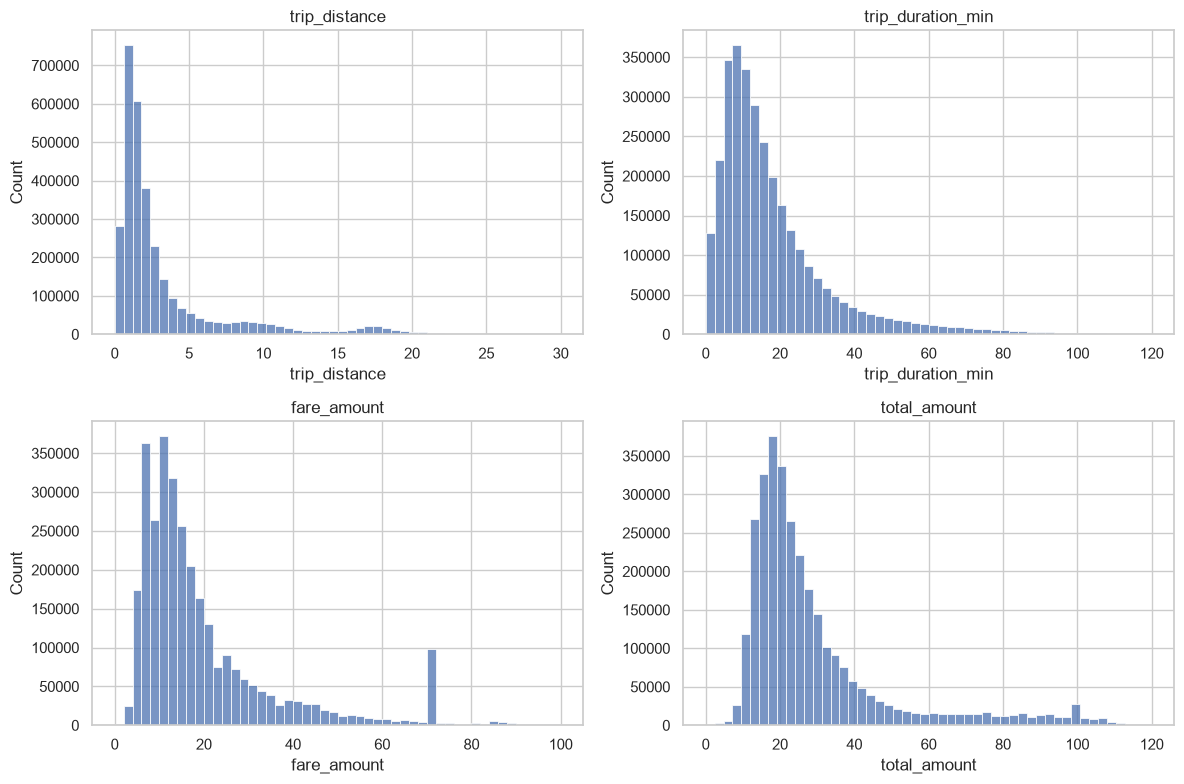

In [14]:
# --- 주요 수치형 변수 분포 시각화 ---
df_pd_clean["trip_duration_min"] = (
    df_pd_clean["tpep_dropoff_datetime"] - df_pd_clean["tpep_pickup_datetime"]
).dt.total_seconds() / 60.0

plot_cols = ["trip_distance", "trip_duration_min", "fare_amount", "total_amount"]
plot_ranges = {
    "trip_distance": (0, 30),
    "trip_duration_min": (0, 120),
    "fare_amount": (0, 100),
    "total_amount": (0, 120),
}

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, col in zip(axes.flat, plot_cols):
    low, high = plot_ranges[col]
    subset = df_pd_clean[col][(df_pd_clean[col] >= low) & (df_pd_clean[col] <= high)]
    sns.histplot(subset, bins=50, ax=ax)
    ax.set_title(col)
fig.tight_layout()
plt.show()

/var/folders/h7/dgj8_k7x2qs2nqcvg2710s2r0000gn/T/ipykernel_25538/2491893175.py:11: UserWarning: Glyph 51452 (\N{HANGUL SYLLABLE JU}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/h7/dgj8_k7x2qs2nqcvg2710s2r0000gn/T/ipykernel_25538/2491893175.py:11: UserWarning: Glyph 50836 (\N{HANGUL SYLLABLE YO}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/h7/dgj8_k7x2qs2nqcvg2710s2r0000gn/T/ipykernel_25538/2491893175.py:11: UserWarning: Glyph 48320 (\N{HANGUL SYLLABLE BYEON}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/h7/dgj8_k7x2qs2nqcvg2710s2r0000gn/T/ipykernel_25538/2491893175.py:11: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/h7/dgj8_k7x2qs2nqcvg2710s2r0000gn/T/ipykernel_25538/2491893175.py:11: UserWarning: Glyph 44036 (\N{HANGUL SYLLABLE GAN}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/h7/dgj8_k7x2qs2nqcvg2710s2r0000gn/T/ipykernel_25538/2491893175.py:11: Use

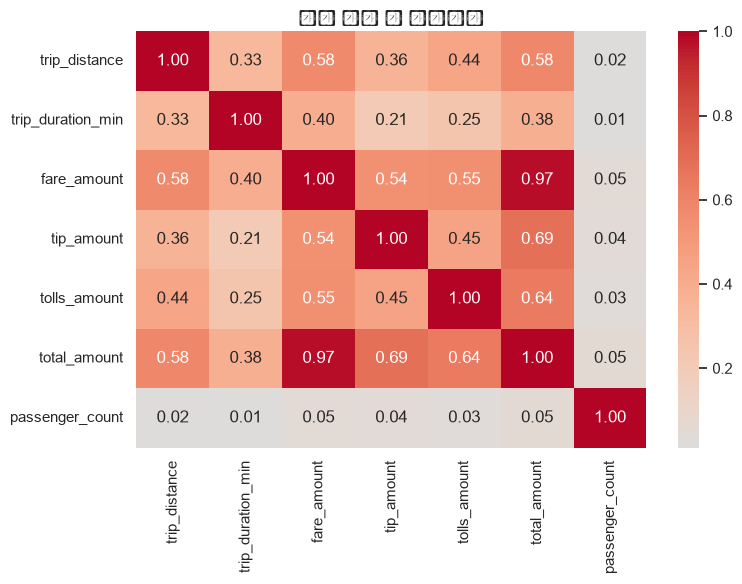

In [15]:
# --- 상관관계 히트맵 ---
corr_cols = [
    "trip_distance", "trip_duration_min", "fare_amount",
    "tip_amount", "tolls_amount", "total_amount", "passenger_count",
]
corr = df_pd_clean[corr_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("주요 변수 간 상관관계")
plt.tight_layout()
plt.show()

/var/folders/h7/dgj8_k7x2qs2nqcvg2710s2r0000gn/T/ipykernel_25538/889241891.py:18: UserWarning: Glyph 49884 (\N{HANGUL SYLLABLE SI}) missing from font(s) Arial.
  fig.tight_layout()
/var/folders/h7/dgj8_k7x2qs2nqcvg2710s2r0000gn/T/ipykernel_25538/889241891.py:18: UserWarning: Glyph 44036 (\N{HANGUL SYLLABLE GAN}) missing from font(s) Arial.
  fig.tight_layout()
/var/folders/h7/dgj8_k7x2qs2nqcvg2710s2r0000gn/T/ipykernel_25538/889241891.py:18: UserWarning: Glyph 45824 (\N{HANGUL SYLLABLE DAE}) missing from font(s) Arial.
  fig.tight_layout()
/var/folders/h7/dgj8_k7x2qs2nqcvg2710s2r0000gn/T/ipykernel_25538/889241891.py:18: UserWarning: Glyph 48324 (\N{HANGUL SYLLABLE BYEOL}) missing from font(s) Arial.
  fig.tight_layout()
/var/folders/h7/dgj8_k7x2qs2nqcvg2710s2r0000gn/T/ipykernel_25538/889241891.py:18: UserWarning: Glyph 50868 (\N{HANGUL SYLLABLE UN}) missing from font(s) Arial.
  fig.tight_layout()
/var/folders/h7/dgj8_k7x2qs2nqcvg2710s2r0000gn/T/ipykernel_25538/889241891.py:18: UserWarn

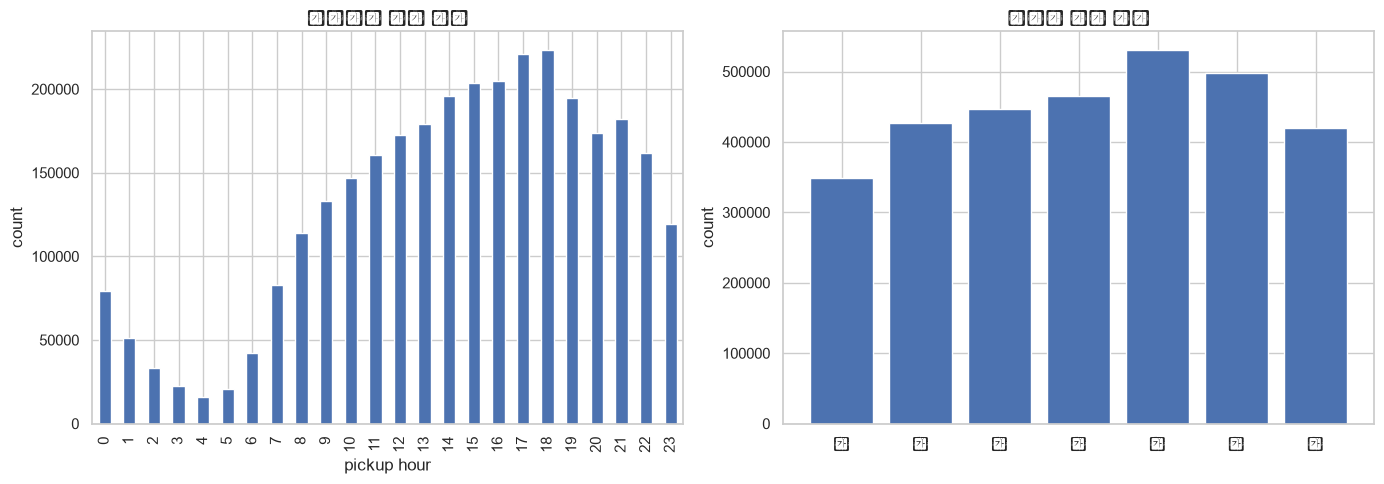

In [16]:
# --- 시간대별 운행 패턴 ---
df_pd_clean["pickup_hour"] = df_pd_clean["tpep_pickup_datetime"].dt.hour
df_pd_clean["pickup_day_of_week"] = df_pd_clean["tpep_pickup_datetime"].dt.dayofweek

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df_pd_clean["pickup_hour"].value_counts().sort_index().plot(kind="bar", ax=axes[0])
axes[0].set_title("시간대별 운행 건수")
axes[0].set_xlabel("pickup hour")
axes[0].set_ylabel("count")

day_labels = ["월", "화", "수", "목", "금", "토", "일"]
counts_by_day = df_pd_clean["pickup_day_of_week"].value_counts().sort_index()
axes[1].bar(day_labels, counts_by_day.values)
axes[1].set_title("요일별 운행 건수")
axes[1].set_ylabel("count")

fig.tight_layout()
plt.show()